In [1]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

In [2]:
from ShockCooling_config import *

In [3]:
#import paths
db_dir, base_dir = get_user_config("shar")

[CONFIG] Using Shar's Darwin setup


In [4]:
#import metric and shared utils
metric, shared_utils = get_metric_and_su() #if this gives a UserWarning, run it again to clear

/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loaded metric module: ShockCooling_metric
[INFO] Loaded shared_utils module


In [5]:
#scientifically correct metric variables values live in MDwarf_config.py file and have been imported
#but you can adjust them here if you want to run tests

#adjusting rate density to be more manageable
rate_density = rate_density / 10


# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="SCE", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        use_kcorrect=use_kcorrect,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths


SCE_den_5.798650076411451e-08_d_None-None_Mpc_z_0.00226-1_ext_True_kcor_True_None


In [6]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /lustre/lrspec/metrics/results/SCE/SCE_den_5.798650076411451e-08_d_None-None_Mpc_z_0.00226-1_ext_True_kcor_True_None_templates.pkl
Loaded templates from /lustre/lrspec/metrics/results/SCE/SCE_den_5.798650076411451e-08_d_None-None_Mpc_z_0.00226-1_ext_True_kcor_True_None_templates.pkl


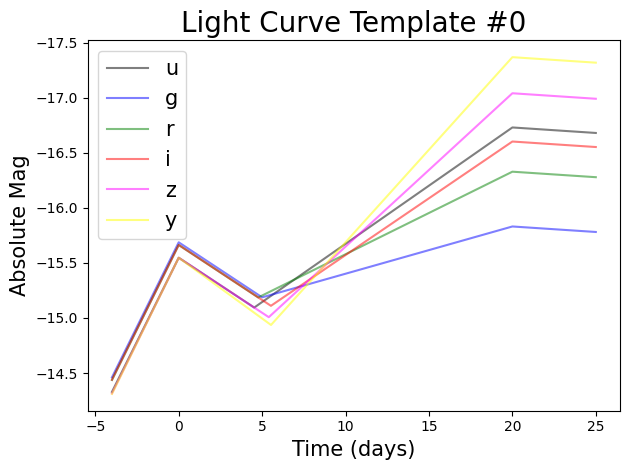

/home/3155/metrics/Multi_Transient_Metrics_Hub/shared_utils.py:156: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={'size': 15})


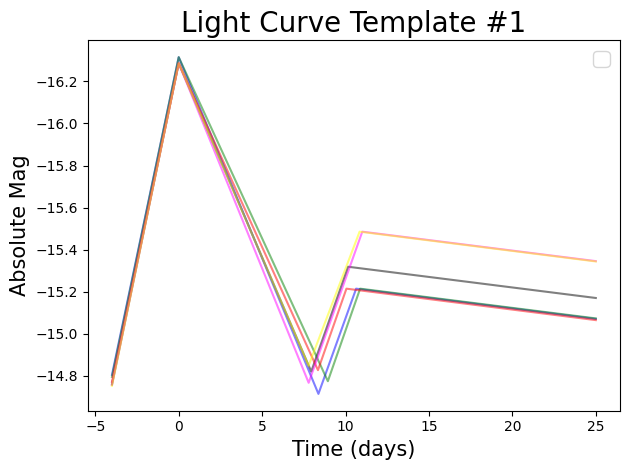

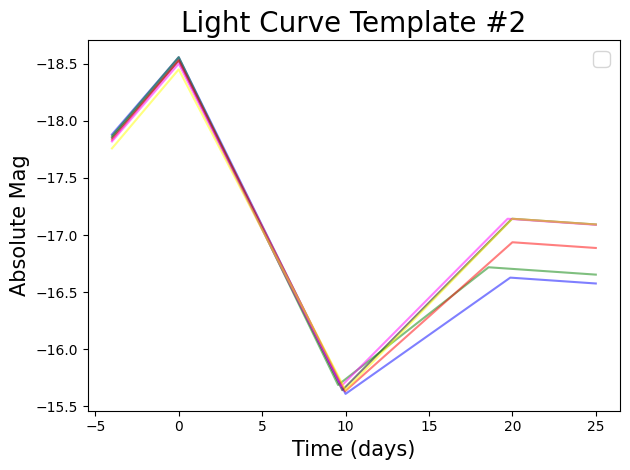

In [7]:
#plot light curves from pkl file if desired
# ylim=(-15, -21)
ylim=None
shared_utils.plot_template_lcs(templates_file, num=3, use_log_time = False,plot_overlap=False,ylim=ylim)

[INFO] Generating population and saving to /lustre/lrspec/metrics/results/SCE/SCE_den_5.798650076411451e-08_d_None-None_Mpc_z_0.00226-1_ext_True_kcor_True_None_population.pkl
[INFO] z_min = 0.00226 -> d_min = 10.008475172186685 Mpc
[INFO] z_max = 1.00000 -> d_max = 3395.634471151566231 Mpc
Simulated 95047 events using rate_density = 5.8e-08
Len ra before masking:  95047


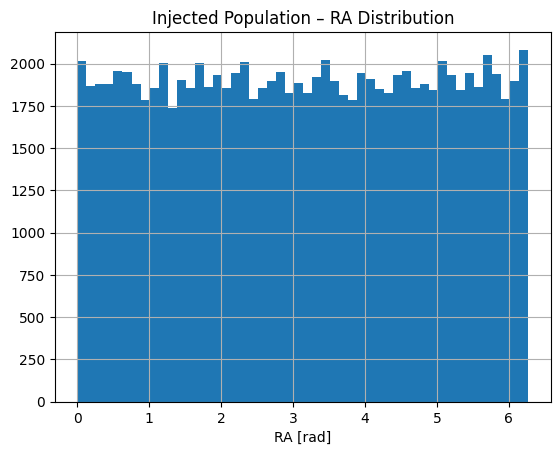

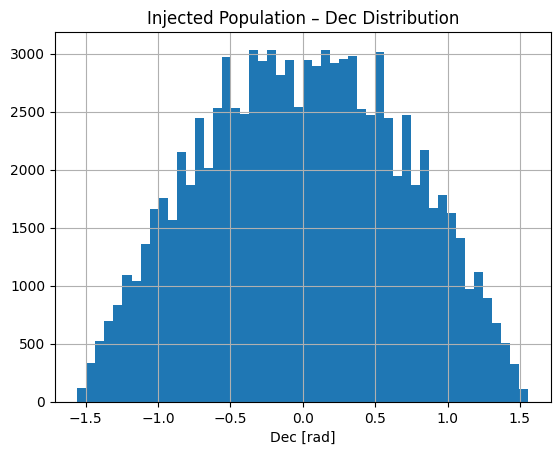

initial peak times:  [2009.88059854 2993.75825369 1328.25635458 ... 3477.72538891 3017.47558463
 1445.98005136]
gal_lat_cut is none


KeyboardInterrupt: 

In [8]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    lc_model=shared_lc_model,                                              
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg
)


## All 10 years

In [22]:
# cadences = ['four_roll_v5.0.0_10yrs']

In [ ]:
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=k_correct_type,
                                 k_correct_arg=k_correct_arg,
                                 use_extinction=use_extinction)

In [18]:
#choose what to run in run_multi_metrics 
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect','characterize'], use_extinction=use_extinction, use_kcorrect=use_kcorrect, k_correct_type=k_correct_type, k_correct_arg=k_correct_arg)



--- Running four_roll_v5.0.0_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b52e8b2f6d0>, <ShockCooling.SCECharacterizeMetric object at 0x2b52e8b2c350>]
                                       Sum                     run  \
four_roll_v5.0.0_10yrs_Detect_Metric  33.0  four_roll_v5.0.0_10yrs   

                                      n_events_full_sky  
four_roll_v5.0.0_10yrs_Detect_Metric              95496  


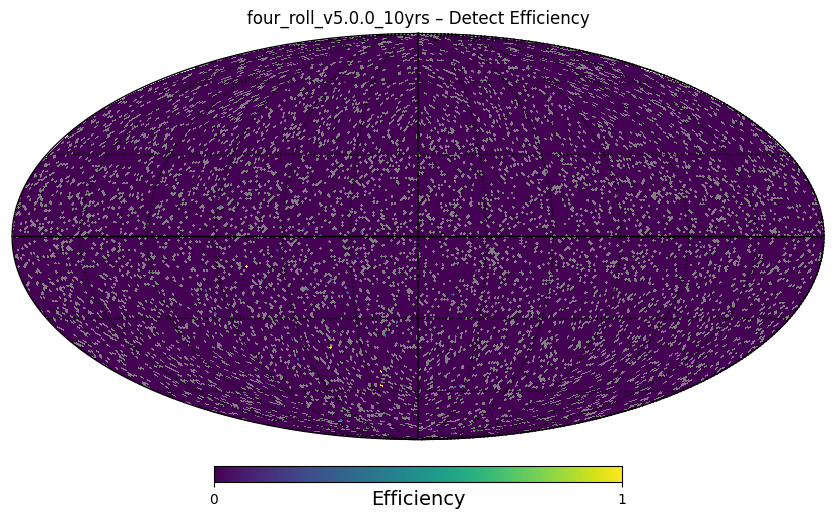

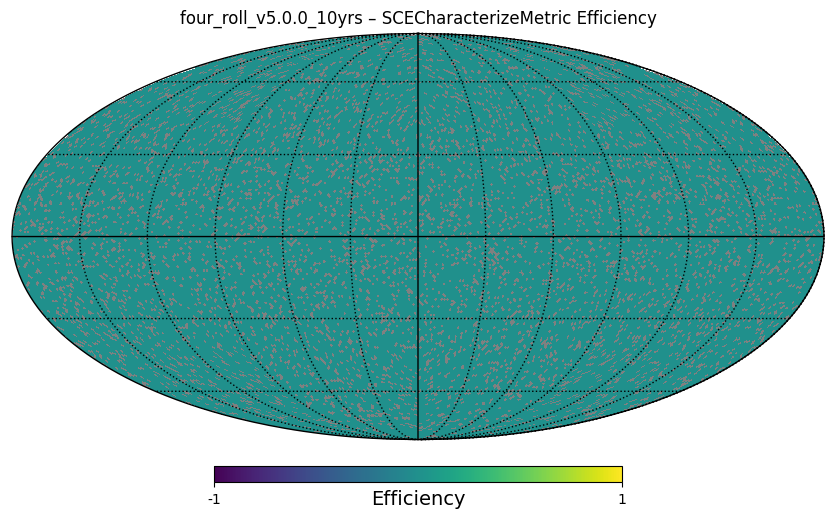

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v5.0.0_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b52e8b2f6d0>, <ShockCooling.SCECharacterizeMetric object at 0x2b52e8b2c350>]


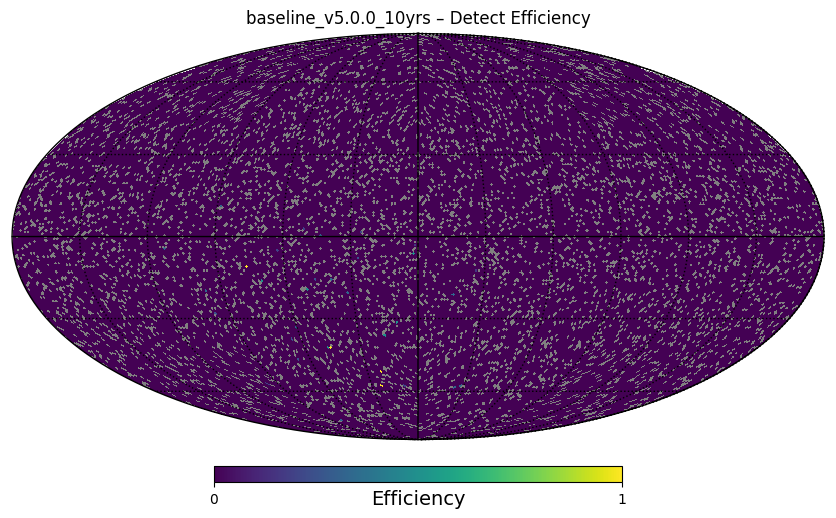

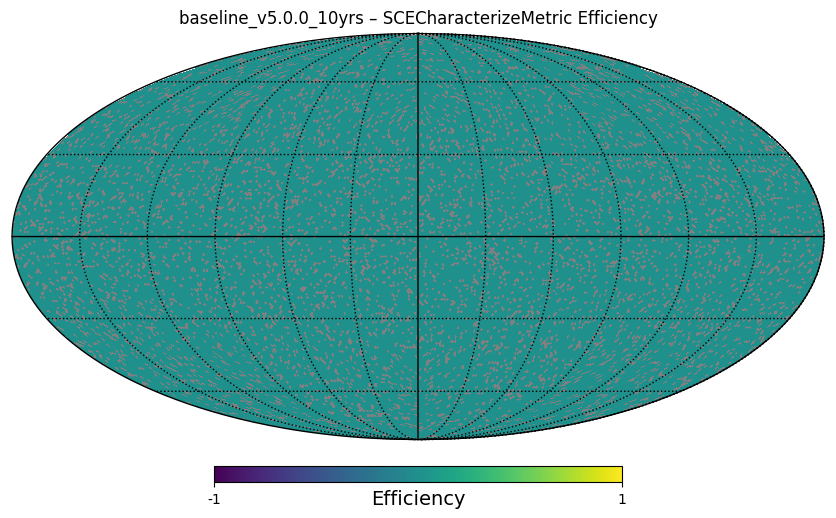

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b52e8b2f6d0>, <ShockCooling.SCECharacterizeMetric object at 0x2b52e8b2c350>]


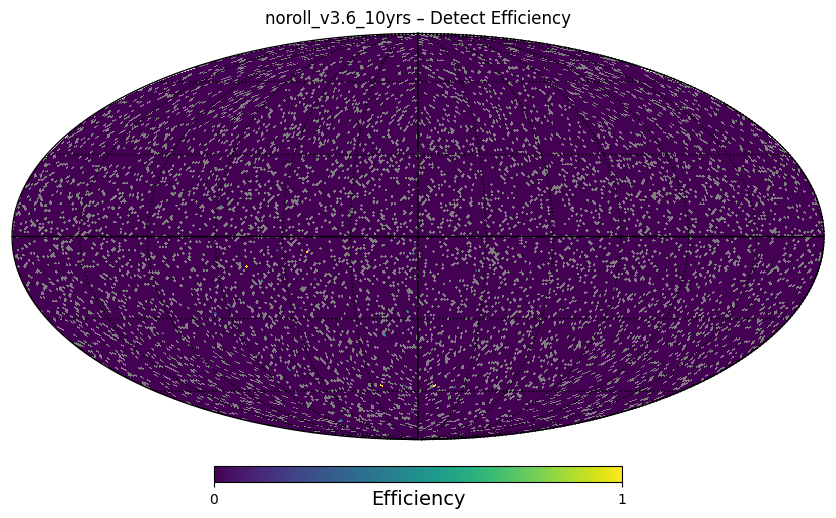

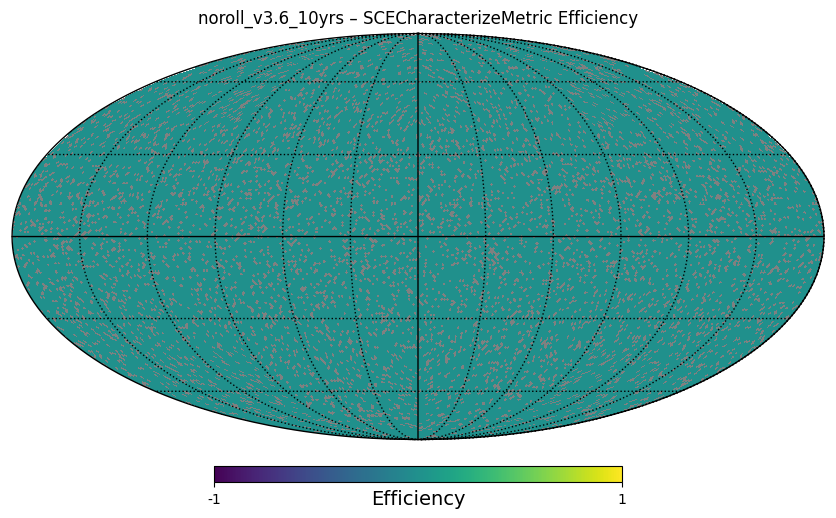

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v3.6_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b52e8b2f6d0>, <ShockCooling.SCECharacterizeMetric object at 0x2b52e8b2c350>]


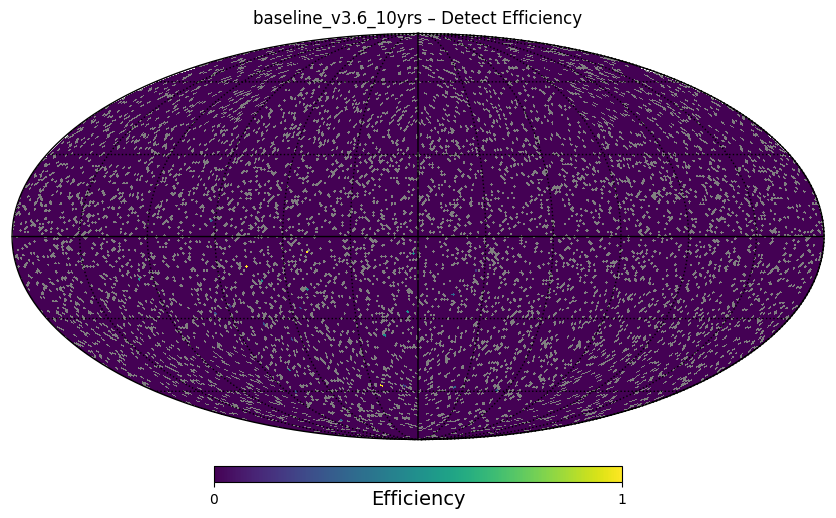

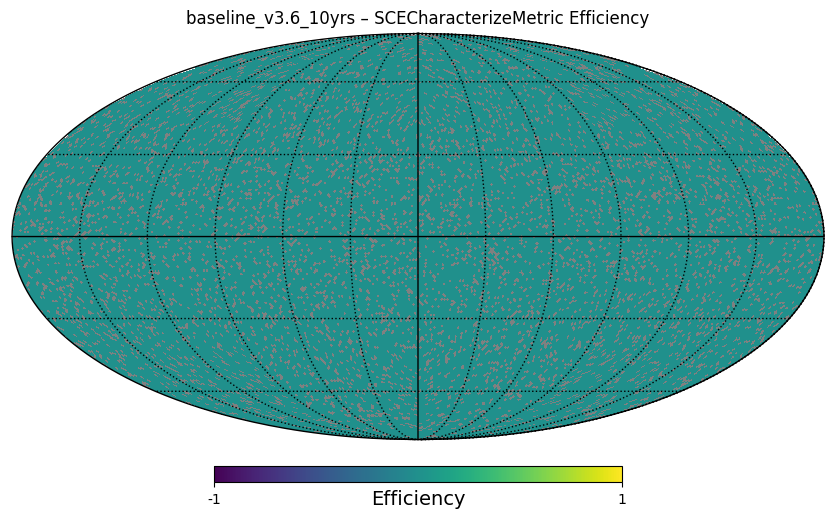

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/SCE/SCE_den_5.798650076411451e-08_d_10.008475172186685-3395.6344711515662_Mpc_z_0.00226-1_ext_True_kcor_True_None_None_multi_summary.csv


In [19]:
sum_df_new = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir=db_dir, storage_dir=storage_dir,summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [20]:
sum_df_new

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,33.0,four_roll_v5.0.0_10yrs,95496
four_roll_v5.0.0_10yrs_SCECharacterizeMetric,0.0,four_roll_v5.0.0_10yrs,95496
baseline_v5.0.0_10yrs_Detect_Metric,33.0,baseline_v5.0.0_10yrs,95496
baseline_v5.0.0_10yrs_SCECharacterizeMetric,0.0,baseline_v5.0.0_10yrs,95496
noroll_v3.6_10yrs_Detect_Metric,23.0,noroll_v3.6_10yrs,95496
noroll_v3.6_10yrs_SCECharacterizeMetric,0.0,noroll_v3.6_10yrs,95496
baseline_v3.6_10yrs_Detect_Metric,24.0,baseline_v3.6_10yrs,95496
baseline_v3.6_10yrs_SCECharacterizeMetric,0.0,baseline_v3.6_10yrs,95496



--- Running four_roll_v5.0.0_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b51dc696290>, <ShockCooling.SCECharacterizeMetric object at 0x2b51db936510>]
                                       Sum                     run  \
four_roll_v5.0.0_10yrs_Detect_Metric  33.0  four_roll_v5.0.0_10yrs   

                                      n_events_full_sky  
four_roll_v5.0.0_10yrs_Detect_Metric              95496  


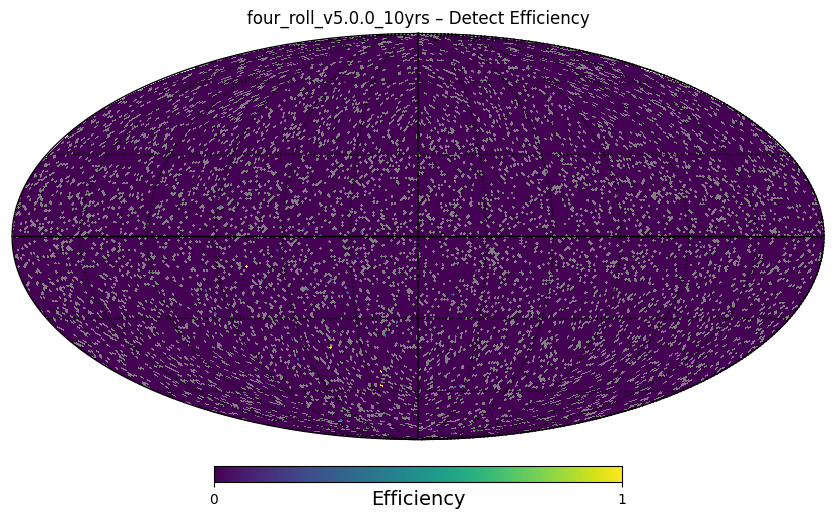

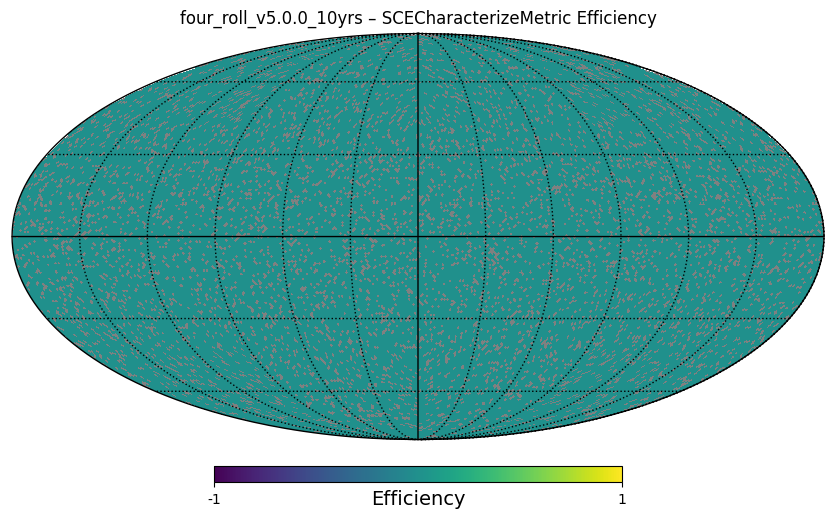

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v5.0.0_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b51dc696290>, <ShockCooling.SCECharacterizeMetric object at 0x2b51db936510>]


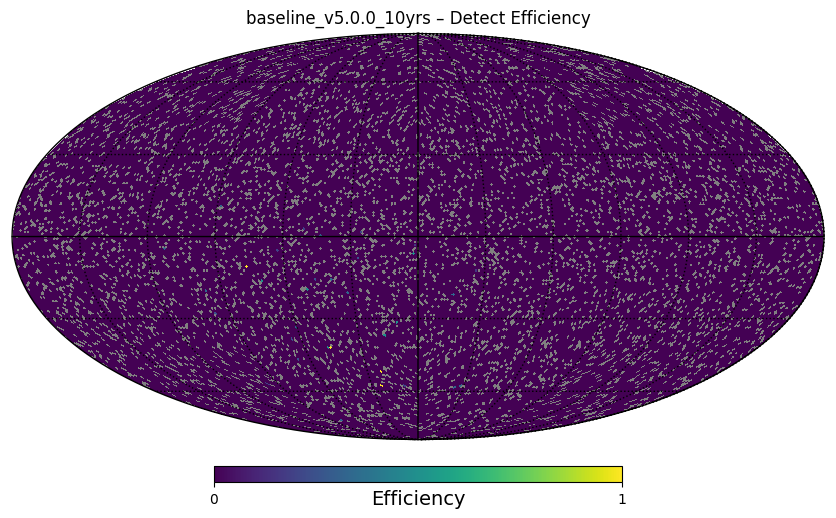

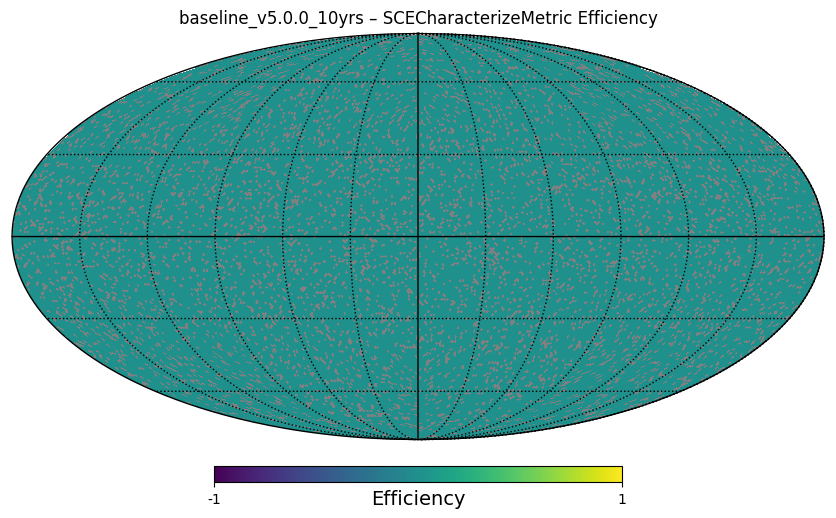

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b51dc696290>, <ShockCooling.SCECharacterizeMetric object at 0x2b51db936510>]


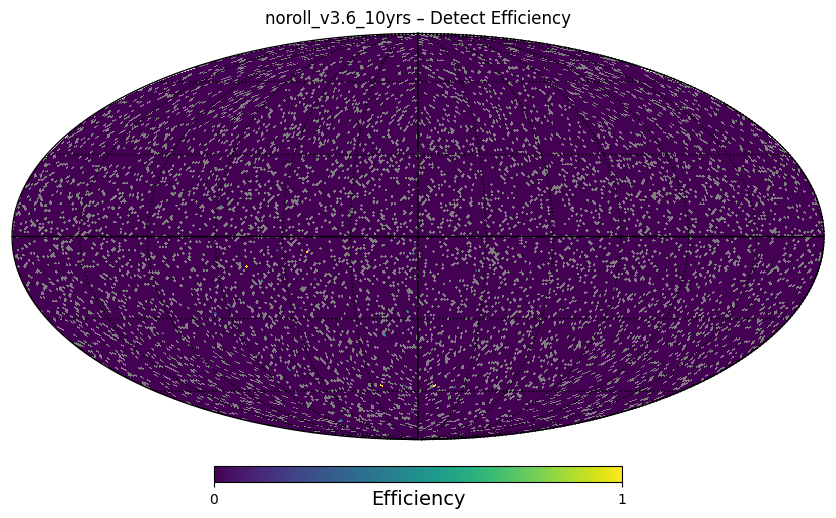

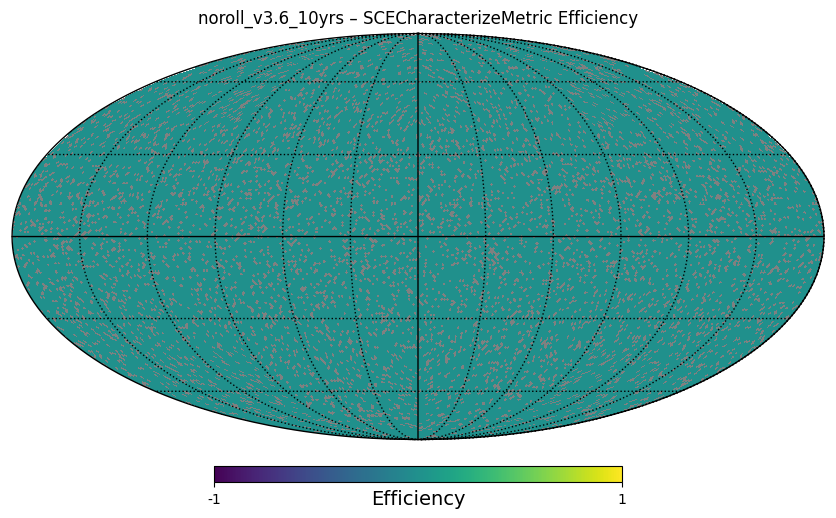

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v3.6_10yrs ---
(2,)
[<ShockCooling.Detect_Metric object at 0x2b51dc696290>, <ShockCooling.SCECharacterizeMetric object at 0x2b51db936510>]


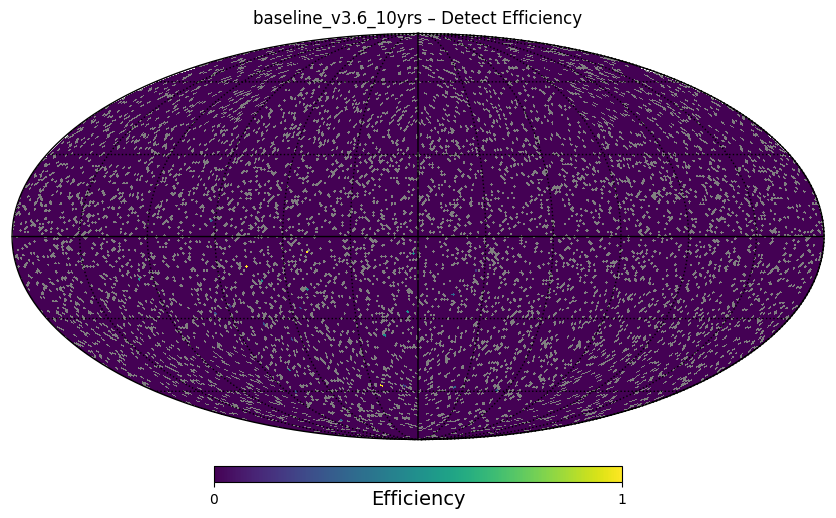

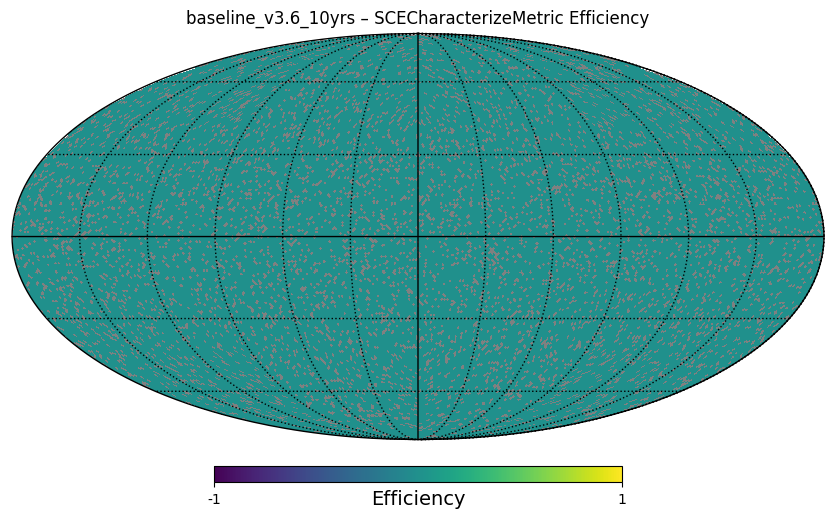

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/SCE/SCE_den_5.798650076411451e-08_d_10.008475172186685-3395.6344711515662_Mpc_z_0.00226-1_ext_True_kcor_True_None_None_multi_summary.csv


In [11]:
sum_df = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir=db_dir, storage_dir=storage_dir,summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [12]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,33.0,four_roll_v5.0.0_10yrs,95496
four_roll_v5.0.0_10yrs_SCECharacterizeMetric,0.0,four_roll_v5.0.0_10yrs,95496
baseline_v5.0.0_10yrs_Detect_Metric,33.0,baseline_v5.0.0_10yrs,95496
baseline_v5.0.0_10yrs_SCECharacterizeMetric,0.0,baseline_v5.0.0_10yrs,95496
noroll_v3.6_10yrs_Detect_Metric,23.0,noroll_v3.6_10yrs,95496
noroll_v3.6_10yrs_SCECharacterizeMetric,0.0,noroll_v3.6_10yrs,95496
baseline_v3.6_10yrs_Detect_Metric,24.0,baseline_v3.6_10yrs,95496
baseline_v3.6_10yrs_SCECharacterizeMetric,0.0,baseline_v3.6_10yrs,95496


In [49]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,39211.0,four_roll_v5.0.0_10yrs,112601
four_roll_v5.0.0_10yrs_SCECharacterizeMetric,339.0,four_roll_v5.0.0_10yrs,112601


In [100]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,1634.0,four_roll_v5.0.0_10yrs,32865
four_roll_v5.0.0_10yrs_LFBOTCharacterizeMetric,575.0,four_roll_v5.0.0_10yrs,32865
baseline_v5.0.0_10yrs_Detect_Metric,1636.0,baseline_v5.0.0_10yrs,32865
baseline_v5.0.0_10yrs_LFBOTCharacterizeMetric,552.0,baseline_v5.0.0_10yrs,32865
noroll_v3.6_10yrs_Detect_Metric,1522.0,noroll_v3.6_10yrs,32865
noroll_v3.6_10yrs_LFBOTCharacterizeMetric,504.0,noroll_v3.6_10yrs,32865
baseline_v3.6_10yrs_Detect_Metric,1513.0,baseline_v3.6_10yrs,32865
baseline_v3.6_10yrs_LFBOTCharacterizeMetric,506.0,baseline_v3.6_10yrs,32865


In [247]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,367.0,four_roll_v4.3.1_10yrs,7881
four_roll_v4.3.1_10yrs_LFBOTCharacterizeMetric,366.0,four_roll_v4.3.1_10yrs,7881
baseline_v4.3.1_10yrs_Detect_Metric,308.0,baseline_v4.3.1_10yrs,7881
baseline_v4.3.1_10yrs_LFBOTCharacterizeMetric,307.0,baseline_v4.3.1_10yrs,7881
noroll_v3.6_10yrs_Detect_Metric,328.0,noroll_v3.6_10yrs,7881
noroll_v3.6_10yrs_LFBOTCharacterizeMetric,328.0,noroll_v3.6_10yrs,7881
baseline_v3.6_10yrs_Detect_Metric,318.0,baseline_v3.6_10yrs,7881
baseline_v3.6_10yrs_LFBOTCharacterizeMetric,318.0,baseline_v3.6_10yrs,7881


(array([ 1.,  2.,  2.,  6.,  7., 20., 32., 59., 41., 44., 35., 43., 50.,
        36., 41., 26., 49., 33., 15., 12.]),
 array([13.27587902, 14.46348086, 15.65108269, 16.83868453, 18.02628636,
        19.21388819, 20.40149003, 21.58909186, 22.7766937 , 23.96429553,
        25.15189737, 26.3394992 , 27.52710104, 28.71470287, 29.9023047 ,
        31.08990654, 32.27750837, 33.46511021, 34.65271204, 35.84031388,
        37.02791571]),
 <BarContainer object of 20 artists>)

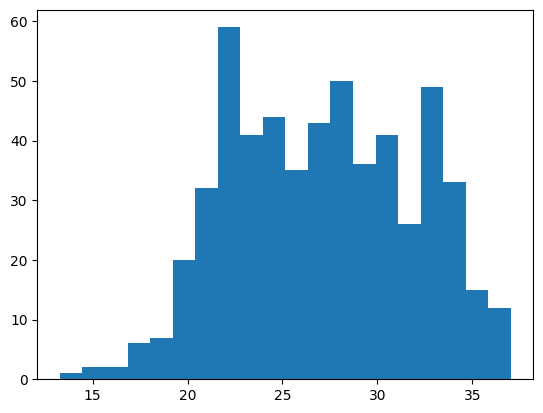

In [90]:
plt.hist(df_obs["peak_apparent_mag_g_noebv"],bins=20)

<Figure size 800x400 with 0 Axes>

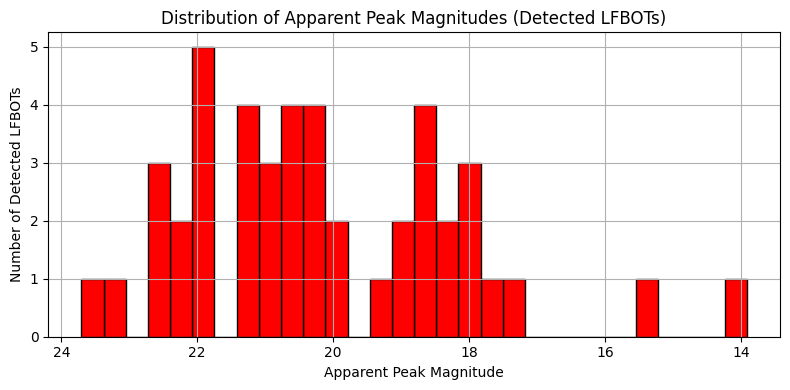

In [95]:
# Convert to numeric safely
valid_peak_mags = pd.to_numeric(detected_df['peak_mag_observed'], errors='coerce')

# Remove NaNs and cap at 99
valid_peak_mags = valid_peak_mags[np.isfinite(valid_peak_mags) & (valid_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(valid_peak_mags, bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected LFBOTs")
plt.title("Distribution of Apparent Peak Magnitudes (Detected LFBOTs)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


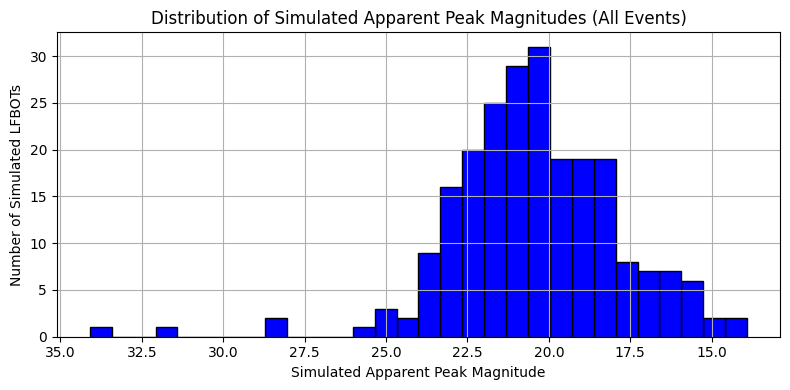

In [113]:
# All simulated events, regardless of detection
all_peak_mags = pd.to_numeric(df_obs['peak_mag_observed'], errors='coerce')
all_peak_mags = all_peak_mags[np.isfinite(all_peak_mags) & (all_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(all_peak_mags, bins=30, edgecolor='black', color='blue')
plt.xlabel("Simulated Apparent Peak Magnitude")
plt.ylabel("Number of Simulated LFBOTs")
plt.title("Distribution of Simulated Apparent Peak Magnitudes (All Events)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


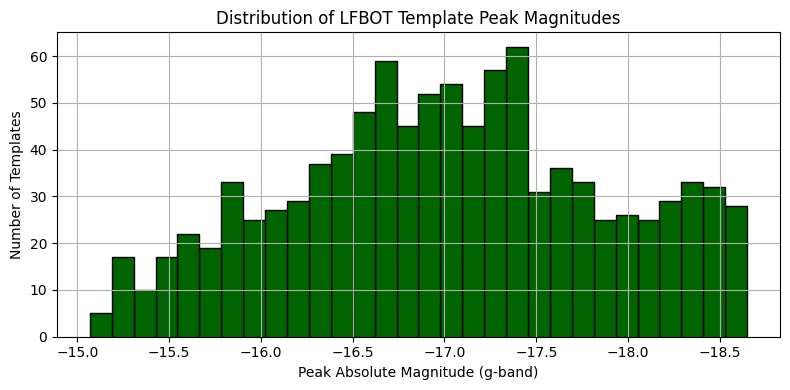

In [9]:
# Assume lc_model is your instance of LC or loaded via shared_utils
g_peak_mags = []

for lc in shared_lc_model.data:
    g_band_mag = lc['g']['mag']
    peak_mag = np.min(g_band_mag)
    g_peak_mags.append(peak_mag)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(g_peak_mags, bins=30, edgecolor='black', color='darkgreen')
plt.xlabel("Peak Absolute Magnitude (g-band)")
plt.ylabel("Number of Templates")
plt.title("Distribution of LFBOT Template Peak Magnitudes")
plt.gca().invert_xaxis()  # brighter to the left
plt.grid(True)
plt.tight_layout()
plt.show()
